# The signal muons and the triggers

The analysis records events with an OR of four displaced-friendly L2 dimuon
paths (both channels use the same list; there is no electron trigger):

| HLT path | min $p_T$ | $|\eta|$ |
|---|---|---|
| `DoubleL2Mu23NoVtx_2Cha` | 23 GeV | < 2.0 |
| `DoubleL2Mu23NoVtx_2Cha_CosmicSeed` | 23 GeV | < 2.0 |
| `DoubleL2Mu25NoVtx_2Cha_Eta2p4` | 25 GeV | < 2.4 |
| `DoubleL2Mu25NoVtx_2Cha_CosmicSeed_Eta2p4` | 25 GeV | < 2.4 |

`NoVtx` means the L2 reconstruction imposes no beamline vertex constraint,
which is what keeps these paths efficient for displaced muons. The trigger
requirement in the 2Mu2E channel must be satisfied by the *single* muon pair
(both muons of one dark photon); in the 4Mu channel any two of the four
muons can satisfy it.

**Method.** Every figure here is built from the HLT decision bits stored in
the signal ntuples, as the ratio of the `genOnly_trigger` channel (status-1
generator leptons, one event cut: the trigger OR above) to the `genOnly`
channel (identical, no event cuts), binned in generator-level quantities.
This measures the absolute trigger efficiency on signal simulation as a
function of truth variables; it involves no reconstruction-level
selection and no data-driven correction (those belong to the corrections
section of the analysis note). Uncertainties: Clopper-Pearson intervals for
the binned turn-on curves; normal-approximation binomial errors for the
per-sample scalar efficiencies (numerically indistinguishable at these
statistics). All shapes are post-production-gen-filter (four leptons with
$p_T > 5$ GeV, $|\eta| < 2.4$), visible as the sharp 5 GeV wall in the
soft spectra.

**Provenance.** Canonical v3 production
(`.../truth_kinematics_forAN/anatomy_v3` on EOS; README has regeneration
commands), all 180 samples at full statistics, unweighted.

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
import mplhep as hep
from hist import rebin as rebin_by

here = os.getcwd()
repo = here.split("/sidm")[0]
for p in (repo, os.path.join(repo, "sidm", "studies", "truth_kinematics_forAN")):
    if p not in sys.path:
        sys.path.insert(1, p)
import _anatomy_lib as lib
import an_style

an_style.set_style()

out = lib.load_v3()
print(f"loaded {len(out)} samples")

MBS = lib.MBS_VALUES
MZD = lib.MZD_VALUES
MBS_COLORS = {m: c for m, c in zip(MBS, plt.cm.viridis(np.linspace(0.0, 0.9, len(MBS))))}
THRESHOLDS = (23, 25)

def draw_thresholds(ax, extra=None):
    for thr in THRESHOLDS:
        ax.axvline(thr, color="gray", ls=":", lw=1)
    if extra is not None:
        ax.axvline(extra, color="#CC79A7", ls="--", lw=1.2)

def threshold_handles(extra=None):
    handles = [Line2D([], [], color="gray", ls=":", lw=1,
                      label="HLT thresholds (23/25 GeV)")]
    if extra is not None:
        handles.append(Line2D([], [], color="#CC79A7", ls="--", lw=1.2,
                              label=rf"{extra} GeV muon $p_T$ cut"))
    return handles

MIN_DEN = 20   # a point is drawn only where its denominator can measure it

def draw_eff(ax, num, den, label, color, xmax=None, min_den=MIN_DEN, **kw):
    '''Efficiency of two same-binned histograms, drawn only where measured.

    Clopper-Pearson on a one- or two-event denominator spans nearly the whole
    range, so those bins carry no information and are dropped rather than
    drawn as full-height bars.'''
    eff, lo, hi, centers = lib.efficiency(num, den)
    ok = np.isfinite(eff) & (den.values() >= min_den)
    if xmax is not None:
        ok &= centers <= xmax
    ax.errorbar(centers[ok], eff[ok],
                yerr=[eff[ok] - lo[ok], hi[ok] - eff[ok]],
                fmt="o", ms=3, lw=1, color=color, label=label, **kw)

def turnon(ax, sample, hist_name, label, color, xmax=None, rebin=1):
    num = lib.get_h(out, sample, hist_name, "genOnly_trigger")
    den = lib.get_h(out, sample, hist_name, "genOnly")
    if rebin > 1:
        num, den = num[::rebin_by(rebin)], den[::rebin_by(rebin)]
    draw_eff(ax, num, den, label, color, xmax=xmax)

def turnon_samples(ax, samples, hist_name, label, color, xmax=None, rebin=1):
    '''Same, summing several samples: the five lifetimes of a mass point share
    one efficiency curve in these variables, so summing them costs nothing and
    buys a factor ~4.5 in statistics.'''
    num = lib.sum_h(out, samples, hist_name, "genOnly_trigger")
    den = lib.sum_h(out, samples, hist_name, "genOnly")
    if rebin > 1:
        num, den = num[::rebin_by(rebin)], den[::rebin_by(rebin)]
    draw_eff(ax, num, den, label, color, xmax=xmax)

def band(h2, axis, lo, hi):
    '''Sum a 2D histogram over [lo, hi) of one axis, leaving the other.'''
    edges = h2.axes[axis].edges
    i0 = int(np.searchsorted(edges, lo, side="left"))
    i1 = int(np.searchsorted(edges, hi, side="left"))
    return h2[{axis: slice(i0, i1, sum)}]

def frac_above(h, threshold):
    # fraction of entries above a bin edge (threshold must sit on an edge);
    # overflow entries are above any in-range threshold, so include them
    edges = h.axes[-1].edges
    v = h.values(flow=True)  # [underflow, bins..., overflow]
    i = int(np.searchsorted(edges, threshold))
    total = v.sum()
    return np.nan if total == 0 else v[i + 1:].sum() / total

loaded 180 samples


## 1. Where the signal muons sit relative to the thresholds

Sub-leading gen-muon $p_T$ (the quantity the dimuon thresholds actually cut
on), for the bound-state mass scan in each channel. Dotted lines: the 23 and
25 GeV HLT thresholds; dashed line: the 26 GeV offline muon cut now in the
base selection (section 5). In the 4Mu channel at $m_{B_s} \geq 500$ GeV nearly
the whole spectrum sits above threshold; in the 2Mu2E channel, where the two
trigger muons share a single dark photon's momentum, 15-28% of events stay
below $\sim$26 GeV even at the highest masses. At 100-150 GeV the
thresholds sit in the bulk of the distribution in both channels and the
trigger sculpts the acceptance.

*Samples: $m_{Z_d}$ = 1.2 GeV, middle lifetimes; channel `genOnly`
(no cuts). In the 2Mu2E channel "sub-leading" is among the two signal
muons; in 4Mu, among all four.*

saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/trigger_subleading_spectra.pdf


'/uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/trigger_subleading_spectra.pdf'

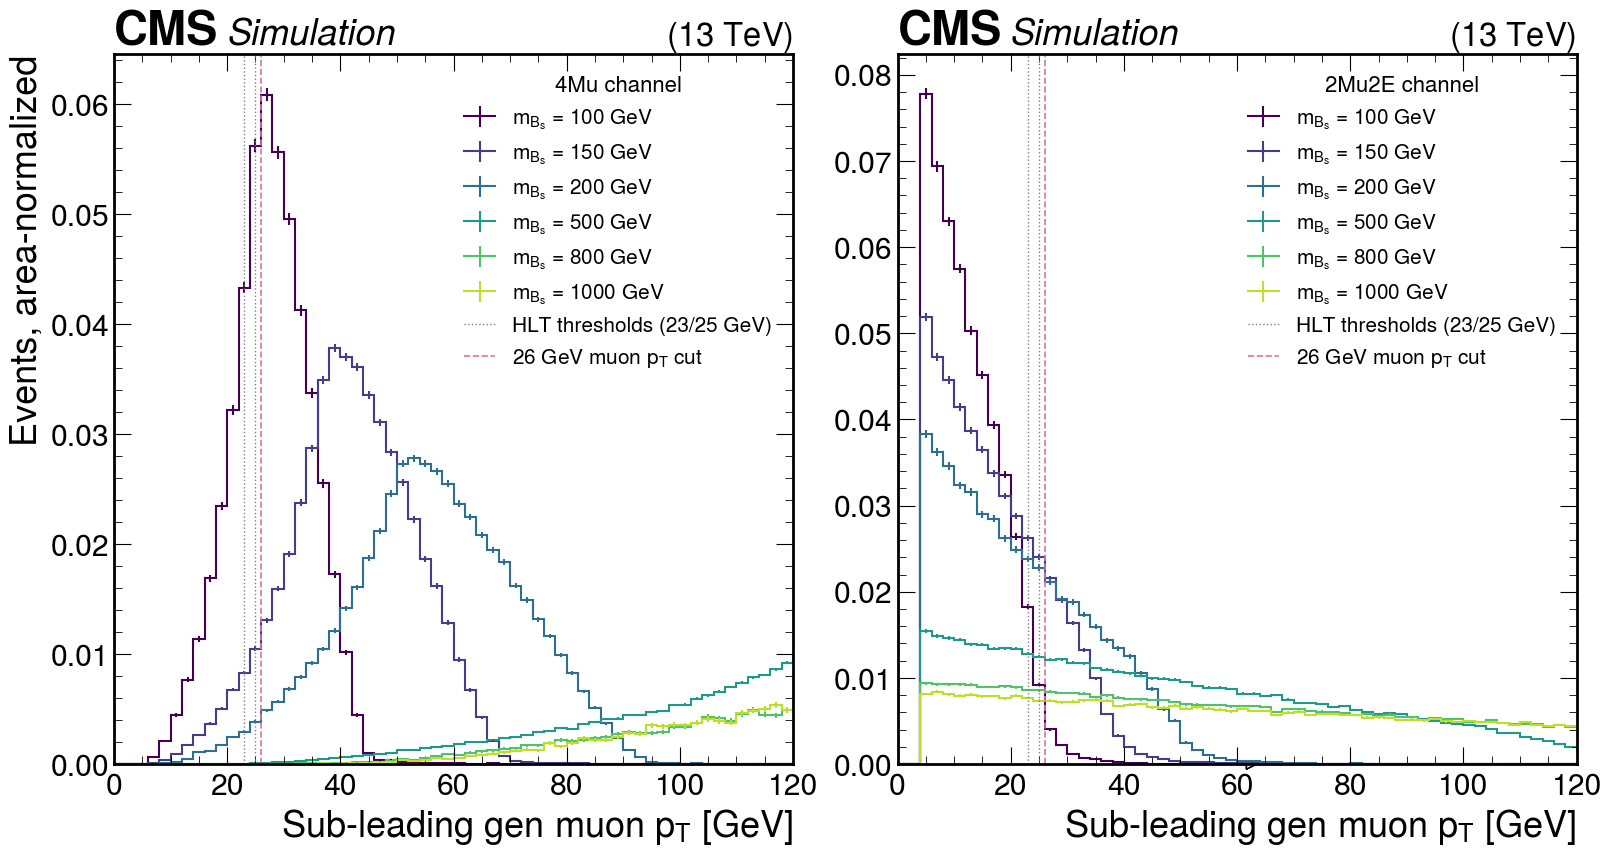

In [2]:
fig, axes = plt.subplots(1, 2, figsize=an_style.WIDE, layout="constrained")
for ax, mode in zip(axes, ["4Mu", "2Mu2E"]):
    for m in MBS:
        hep.histplot(lib.get_h(out, lib.mid_ctau(out, mode, m, 1.2), "genMu1_pt"),
                     ax=ax, density=True, label=rf"$m_{{B_s}}$ = {m:g} GeV",
                     color=MBS_COLORS[m])
    draw_thresholds(ax, extra=26)
    ax.set_xlabel(r"Sub-leading gen muon $p_T$ [GeV]")
    ax.set_xlim(0, 120)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles + threshold_handles(extra=26), labels
              + [h.get_label() for h in threshold_handles(extra=26)],
              fontsize=15, title_fontsize=16, title=f"{mode} channel",
              loc="upper right")
axes[0].set_ylabel("Events, area-normalized")   # shared quantity, labelled once
an_style.cms_sim_labels(axes)
an_style.save(fig, "trigger_subleading_spectra")

## 2. Efficiency turn-ons vs sub-leading muon $p_T$

The trigger OR's efficiency as a function of the sub-leading gen-muon
$p_T$. In the 4Mu channel the turn-on rises through the 23-25 GeV
thresholds and flattens by the high twenties at 0.8-0.95, with the heaviest
mass points lowest; their tighter pairs pay an L2 merging cost. The 2Mu2E
channel never develops a true plateau: efficiency peaks at 0.6-0.67 near
35 GeV and then *declines* along the spectrum, to 0.28-0.43 at 120 GeV for
the heavy points. The reason is kinematic: at fixed $m_{B_s}$ a harder
symmetric pair is a more collimated pair, and in 2Mu2E the single $\mu\mu$
pair must fire the dimuon trigger by itself, so the merging loss grows with
$p_T$ (consistent with the efficiency drop below $\Delta R \sim 0.01$ in
the next section). What changes between mass points is therefore both how
much of the spectrum (section 1) sits under the curve and, in 2Mu2E, the
curve itself.

saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/trigger_turnons_pt.pdf


'/uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/trigger_turnons_pt.pdf'

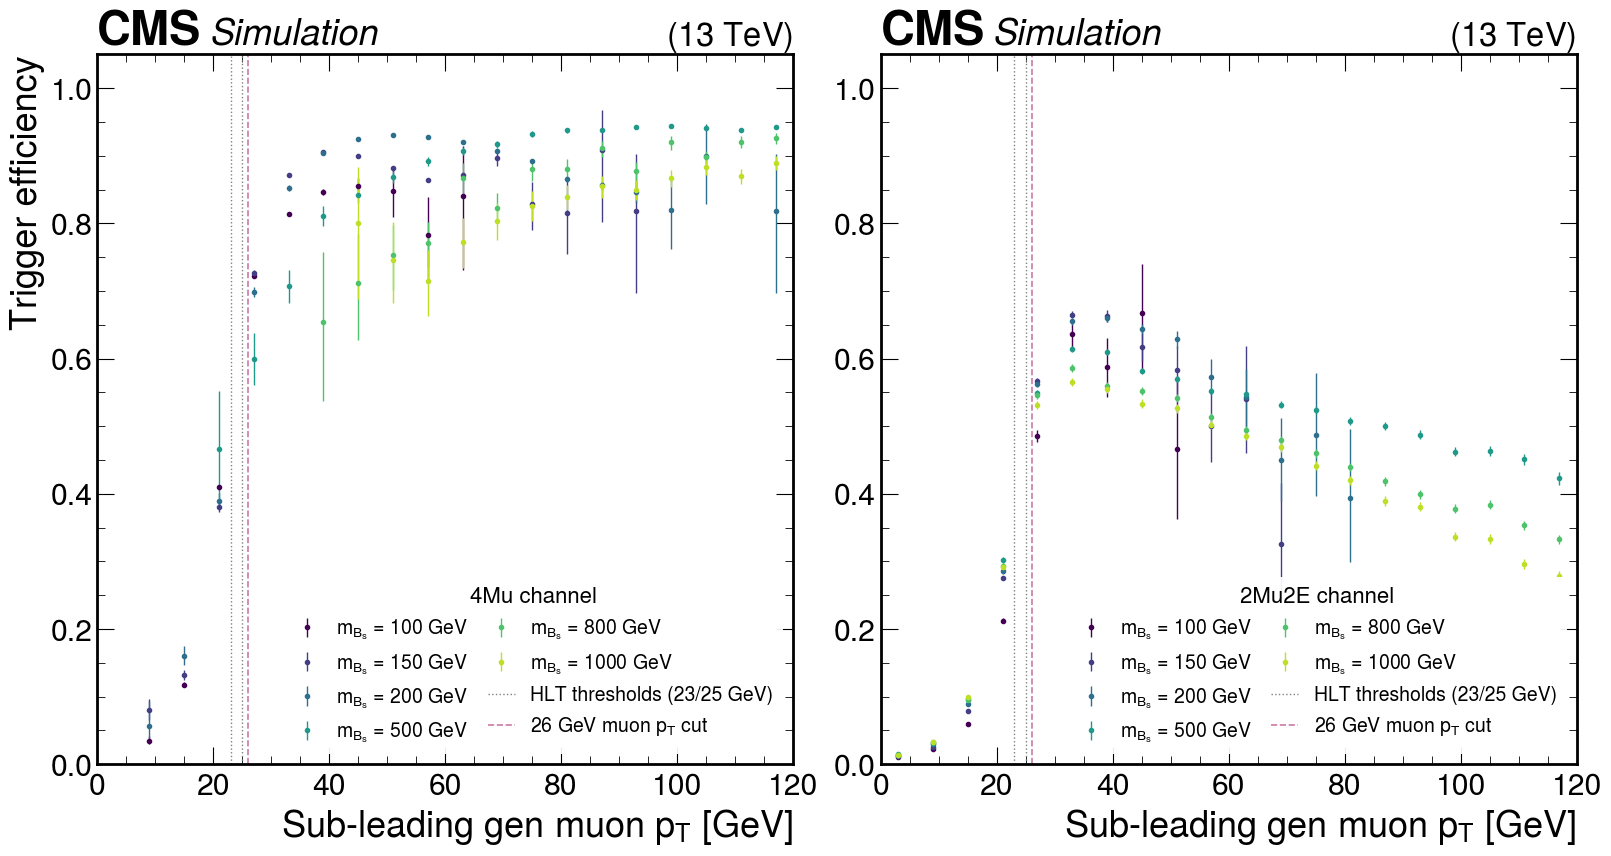

In [3]:
fig, axes = plt.subplots(1, 2, figsize=an_style.WIDE, layout="constrained")
for ax, mode in zip(axes, ["4Mu", "2Mu2E"]):
    for m in MBS:
        turnon(ax, lib.mid_ctau(out, mode, m, 1.2), "genMu1_pt",
               rf"$m_{{B_s}}$ = {m:g} GeV", MBS_COLORS[m], xmax=120, rebin=3)
    draw_thresholds(ax, extra=26)
    ax.set_xlabel(r"Sub-leading gen muon $p_T$ [GeV]")
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 1.05)
    handles, labels = ax.get_legend_handles_labels()
    # two columns keep the legend inside the lower-right block; the low-count
    # bins there carry error bars a metre long, so it needs an opaque backing
    ax.legend(handles + threshold_handles(extra=26), labels
              + [h.get_label() for h in threshold_handles(extra=26)],
              fontsize=14, title_fontsize=16, loc="lower right", ncol=2,
              columnspacing=1.0, handlelength=1.4, frameon=True,
              facecolor="white", edgecolor="none", framealpha=0.92,
              title=f"{mode} channel")
axes[0].set_ylabel("Trigger efficiency")
an_style.cms_sim_labels(axes)
an_style.save(fig, "trigger_turnons_pt")

## 3. Efficiency vs displacement and collimation

Both variables, for the same three samples in each panel. Left: trigger
efficiency against the $\mu\mu$ dark photon's $l_{xy}$, the displaced-trigger
question. The `NoVtx` paths hold up into the metre range, and the three masses
differ in both level and reach: at small $l_{xy}$ the lightest dark photon is
twice as efficient as the heaviest (0.57 against 0.27), which is the
muon-velocity floor of the two-body decay -- at $m_{Z_d} = 0.25$ GeV,
$\beta^* = 0.53$ forces a nearly even $p_T$ sharing, while at 5 GeV
$\beta^* \to 1$ opens the full sharing range and one leg is often too soft for
the threshold. The heaviest dark photon then survives displacement furthest:
its efficiency halves at 332 cm against 212 cm for the two lighter masses, and
it is still measurable at 492 cm, where the others have died by about 270 cm.

Right: efficiency against the pair opening angle $\Delta R(\mu,\mu)$, the
collimation question. The three masses occupy separate ranges of opening angle,
since $\Delta R \approx 2\beta^* m_{Z_d}/p_T$ ties the angle to the mass, and
each rises to a peak and falls: 0.57 at $\Delta R = 0.003$ for 0.25 GeV, 0.58 at
0.024 for 1.2 GeV, 0.48 at 0.094 for 5 GeV. The fall toward small angle is
visible within the 0.25 GeV sample itself, from 0.57 at the peak to 0.36 below
$\Delta R = 5 \times 10^{-4}$, where the `2Cha` two-chamber requirement and L2
muon separation start to cost.

*These curves use the 2Mu2E samples deliberately: there the event has exactly
one $\mu\mu$ dark photon and the $ee$ pair cannot fire the dimuon paths, so
the event-level trigger decision is genuinely the response to that one pair.
In the 4Mu channel the partner pair can also fire the trigger, which would
dilute the dependence toward its event-level average. Each curve sums the five
lifetimes of its mass point: lifetime moves events along the $l_{xy}$ axis
without changing the efficiency at a given $l_{xy}$, so summing costs nothing
and buys a factor $\sim 4.5$ in statistics. Points are drawn only where the
denominator holds at least 20 dark photons.*

saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/trigger_eff_lxy_dR.pdf


'/uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/trigger_eff_lxy_dR.pdf'

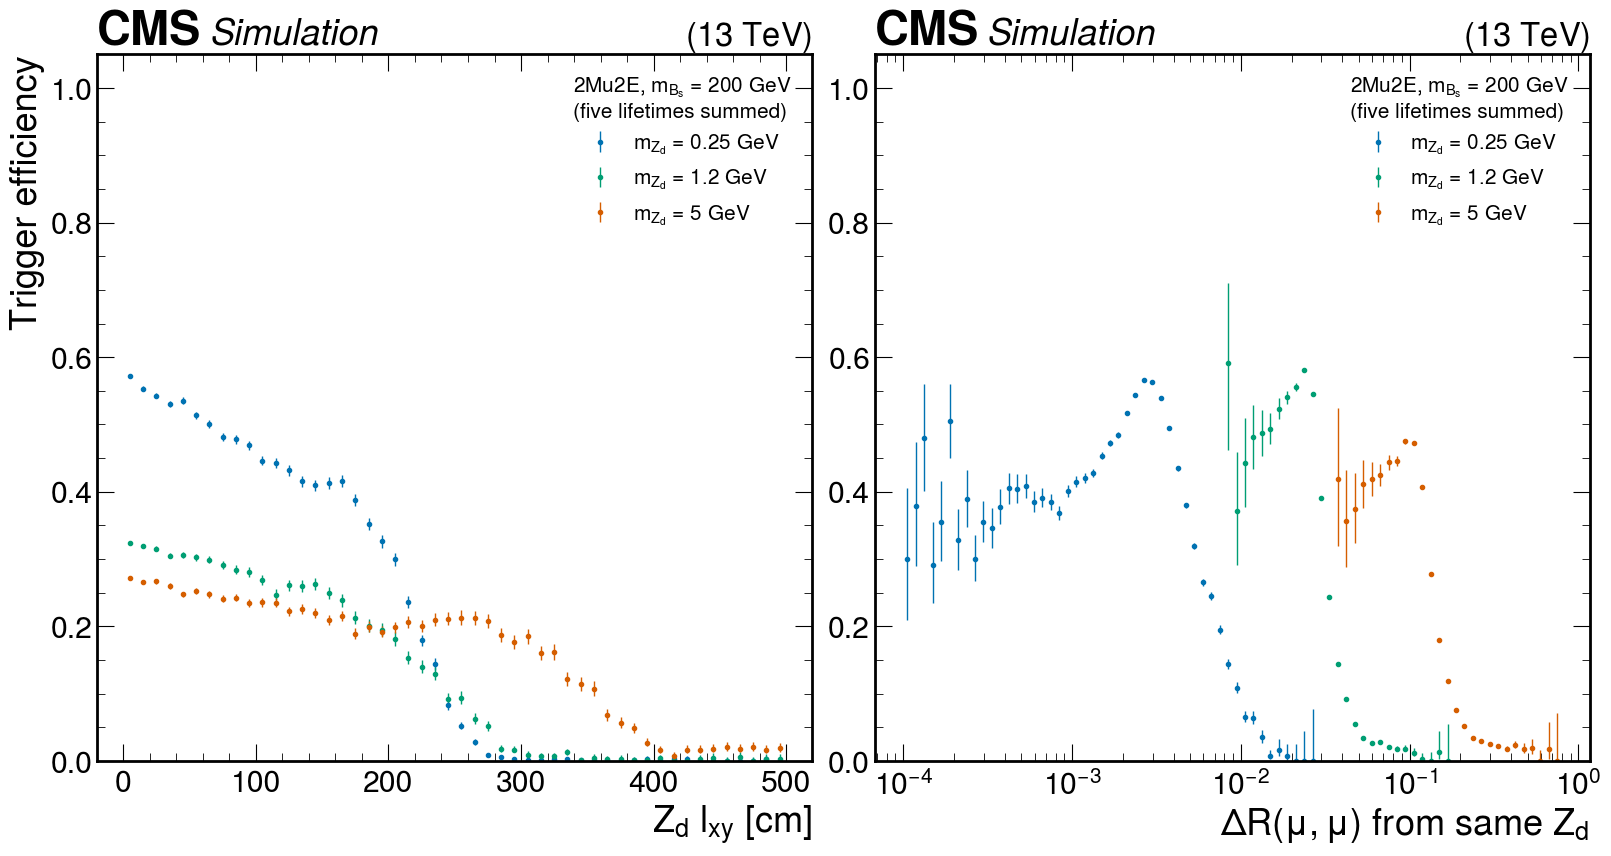

In [4]:
MZD_COLORS = {0.25: "#0072B2", 1.2: "#009E73", 5.0: "#D55E00"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=an_style.WIDE, layout="constrained")
for mzd, color in MZD_COLORS.items():
    samples = lib.select_samples(out, mode="2Mu2E", mbs=200.0, mzd=mzd)
    label = rf"$m_{{Z_d}}$ = {mzd:g} GeV"
    turnon_samples(ax1, samples, "genAs_toMu_lxy", label, color, rebin=2)
    turnon_samples(ax2, samples, "genA_toMu_daughters_dR_logx", label, color)
ax1.set_xlabel(r"$Z_d$ $l_{xy}$ [cm]")
ax2.set_xscale("log")
ax2.set_xlabel(r"$\Delta R(\mu, \mu)$ from same $Z_d$")
for ax in (ax1, ax2):
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=15, loc="upper right",
              title="2Mu2E, $m_{B_s}$ = 200 GeV\n(five lifetimes summed)",
              title_fontsize=15)
ax1.set_ylabel("Trigger efficiency")
an_style.cms_sim_labels((ax1, ax2))
an_style.save(fig, "trigger_eff_lxy_dR")

## 3b. Each variable in bins of the other

The two dependences above are entangled: a sample's opening angle is set by
$\Delta R \approx 2\beta^* m_{Z_d}/p_T$, so scanning the grid moves collimation
and momentum together, and any single curve mixes them. Binning in one variable
while plotting against the other separates them, and it also makes combining
samples legitimate: once the bin fixes the quantity that drives the difference,
samples that differ only in how they populate that quantity can be added
together. Both panels therefore use **every 2Mu2E sample** (all masses, all
lifetimes).

Left: efficiency against opening angle, in bands of dark-photon $p_T$. The loss
toward small angle survives at fixed momentum, so it is an angular effect and
not the soft-muon turn-on in disguise, and it weakens as the pair hardens: the
efficiency below $\Delta R = 10^{-3}$ is 16% of that band's peak at
$p_T$ = 25-50 GeV, 41% at 50-100 GeV, and 84% at 100-300 GeV. Read these bands
remembering that at fixed $p_T$ the opening angle is largely a relabelling of
$m_{Z_d}$, so the small-angle end of each band is its lightest dark photon.

Right: efficiency against dark-photon $p_T$, in bands of opening angle. Every
band shows the same turn-on, reaching 25% between 57 and 105 GeV of dark-photon
$p_T$ and flattening at 0.30-0.38 above 100 GeV. The ordering is not simply
"tighter is worse": the widest band, $\Delta R$ = 0.03-0.1, is the one that
turns on latest and saturates lowest (0.37 at its best bin against 0.53-0.57 for
the others), because a wide pair at fixed momentum is a heavy dark photon, whose
unsuppressed $\beta^*$ hands one muon too little $p_T$ to reach the threshold.

*The one variable this pair cannot separate is displacement: the stored
histograms hold the joint distribution of opening angle with $p_T$, but not
with $l_{xy}$, so an $l_{xy}$-binned version needs a new two-dimensional
histogram and a rerun.*

combined 90 2Mu2E samples: 11632304 dark photons, 3303581 triggered


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/trigger_eff_conditioned.pdf


'/uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/trigger_eff_conditioned.pdf'

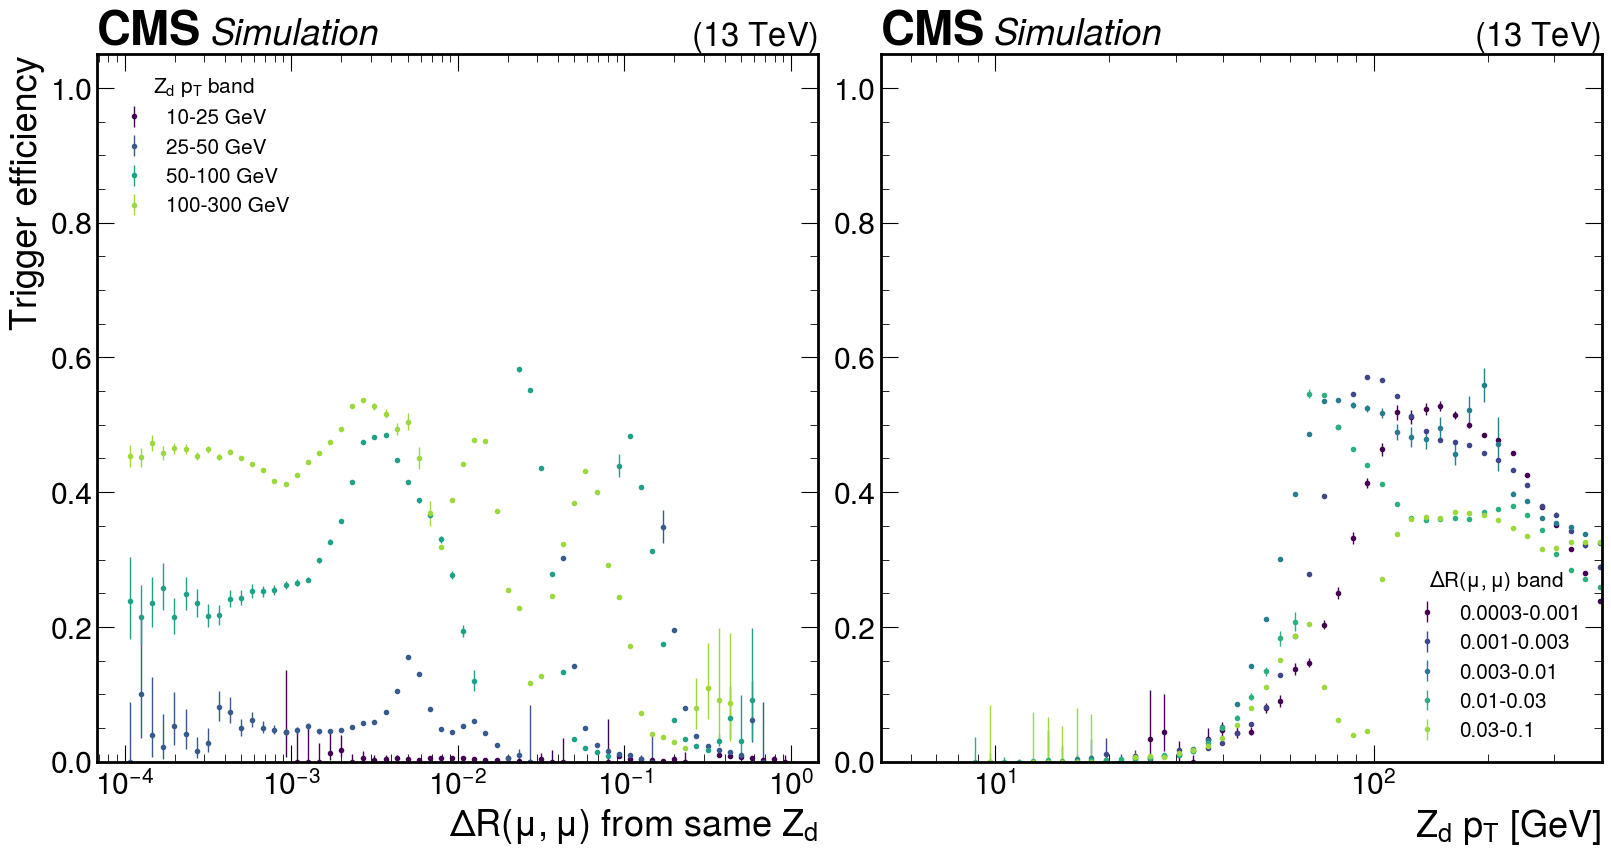

In [5]:
all_2mu2e = lib.select_samples(out, mode="2Mu2E")
num2 = lib.sum_h(out, all_2mu2e, "genA_toMu_daughters_dR_vs_pt", "genOnly_trigger")
den2 = lib.sum_h(out, all_2mu2e, "genA_toMu_daughters_dR_vs_pt", "genOnly")
print(f"combined {len(all_2mu2e)} 2Mu2E samples: "
      f"{den2.values().sum():.0f} dark photons, {num2.values().sum():.0f} triggered")

PT_BANDS = [(10, 25), (25, 50), (50, 100), (100, 300)]
DR_BANDS = [(3e-4, 1e-3), (1e-3, 3e-3), (3e-3, 1e-2), (1e-2, 3e-2), (3e-2, 1e-1)]
cmap = plt.cm.viridis

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=an_style.WIDE, layout="constrained")
for i, (lo, hi) in enumerate(PT_BANDS):
    color = cmap(i / max(len(PT_BANDS) - 1, 1) * 0.85)
    draw_eff(ax1, band(num2, "genA_toMu_pt", lo, hi),
             band(den2, "genA_toMu_pt", lo, hi),
             rf"{lo:g}-{hi:g} GeV", color)
ax1.set_xscale("log")
ax1.set_xlabel(r"$\Delta R(\mu, \mu)$ from same $Z_d$")
ax1.set_ylabel("Trigger efficiency")
ax1.legend(fontsize=15, title=r"$Z_d$ $p_T$ band", title_fontsize=15,
           loc="upper left")

for i, (lo, hi) in enumerate(DR_BANDS):
    color = cmap(i / max(len(DR_BANDS) - 1, 1) * 0.85)
    draw_eff(ax2, band(num2, "genA_toMu_daughters_dR", lo, hi),
             band(den2, "genA_toMu_daughters_dR", lo, hi),
             rf"{lo:g}-{hi:g}", color)
ax2.set_xscale("log")
ax2.set_xlim(5, 400)
ax2.set_xlabel(r"$Z_d$ $p_T$ [GeV]")
ax2.legend(fontsize=15, title=r"$\Delta R(\mu,\mu)$ band", title_fontsize=15,
           loc="lower right")

for ax in (ax1, ax2):
    ax.set_ylim(0, 1.05)
an_style.cms_sim_labels((ax1, ax2))
an_style.save(fig, "trigger_eff_conditioned")

## 4. Total trigger efficiency across the grid

Per-sample event-level trigger efficiency (triggered events / all events,
`genOnly` denominators), shown as the median over the five lifetimes of
each mass point (left: 4Mu; right: 2Mu2E), with the lifetime dependence at
one benchmark point below. The trends compose sections 1-3: efficiency
rises with $m_{B_s}$ up to $\sim$500 GeV (harder muons) and then declines
toward 1000 GeV in *both* channels as collimation losses take over. At
fixed $m_{B_s}$, efficiency mostly *rises* toward small $m_{Z_d}$: the
$\beta^* = 0.53$ velocity floor at 0.25 GeV forbids very asymmetric pairs
and so hardens the sub-leading muon, until the heaviest masses, where
merging reverses the trend. The 4Mu channel spans 0.58-0.95; the 2Mu2E
channel, whose single $\mu\mu$ pair must do all the triggering, spans
0.08-0.54, with single-digit-percent efficiency in its
$m_{B_s} = 100$ GeV column. Efficiency also degrades with lifetime
(displaced L2 losses). The light 2Mu2E corners motivate the
trigger-improvement studies referenced in the analysis note's corrections
section.

saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/trigger_eff_grid.pdf


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/trigger_eff_vs_ctau.pdf


'/uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/trigger_eff_vs_ctau.pdf'

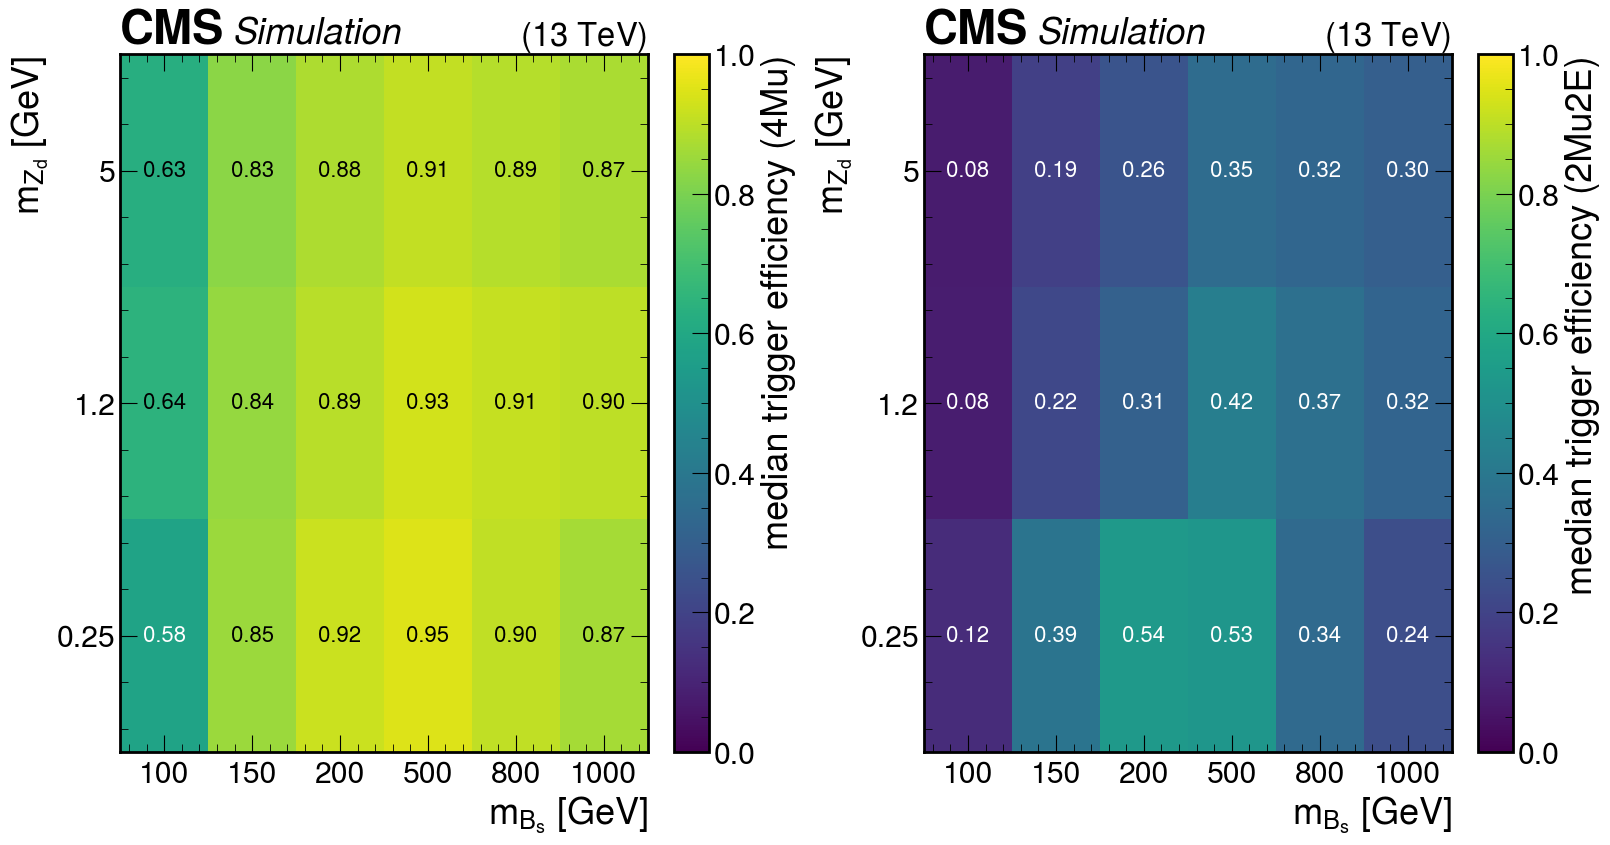

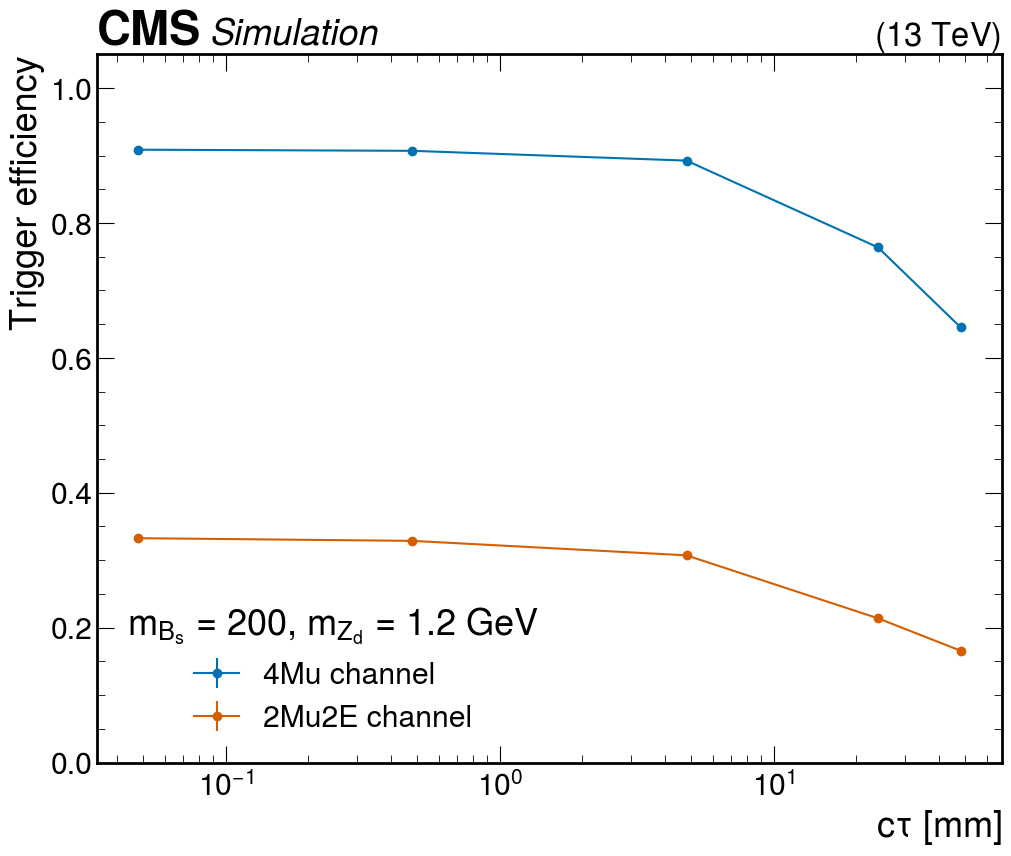

In [6]:
fig, axes = plt.subplots(1, 2, figsize=an_style.WIDE, layout="constrained")
for ax, mode in zip(axes, ["4Mu", "2Mu2E"]):
    grid = np.zeros((len(MZD), len(MBS)))
    for i, mzd in enumerate(MZD):
        for j, mbs in enumerate(MBS):
            effs = [lib.trigger_eff(out, s)[0]
                    for s in lib.select_samples(out, mode=mode, mbs=mbs, mzd=mzd)]
            grid[i, j] = np.nanmedian(effs)
    pcm = ax.pcolormesh(np.arange(len(MBS) + 1), np.arange(len(MZD) + 1), grid,
                        norm=Normalize(0, 1), cmap="viridis")
    fig.colorbar(pcm, ax=ax, label=f"median trigger efficiency ({mode})")
    for i in range(len(MZD)):
        for j in range(len(MBS)):
            tc = "black" if pcm.norm(grid[i, j]) > 0.6 else "white"
            ax.text(j + 0.5, i + 0.5, f"{grid[i, j]:.2f}", ha="center",
                    va="center", color=tc, fontsize=16)
    ax.set_xticks(np.arange(len(MBS)) + 0.5, [f"{m:g}" for m in MBS])
    ax.set_yticks(np.arange(len(MZD)) + 0.5, [f"{m:g}" for m in MZD])
    ax.set_xlabel(r"$m_{B_s}$ [GeV]")
    ax.set_ylabel(r"$m_{Z_d}$ [GeV]")
an_style.cms_sim_labels(axes)
an_style.save(fig, "trigger_eff_grid")

fig, ax = plt.subplots(figsize=an_style.SINGLE, layout="constrained")
for mode, color in [("4Mu", "#0072B2"), ("2Mu2E", "#D55E00")]:
    names = sorted(lib.select_samples(out, mode=mode, mbs=200.0, mzd=1.2),
                   key=lambda n: lib.parse_sample(n)["ctau_mm"])
    cts = [lib.parse_sample(n)["ctau_mm"] for n in names]
    effs, errs = zip(*[lib.trigger_eff(out, n) for n in names])
    ax.errorbar(cts, effs, yerr=errs, fmt="o-", color=color, label=f"{mode} channel")
ax.set_xscale("log")
ax.set_xlabel(r"$c\tau$ [mm]")
ax.set_ylabel("Trigger efficiency")
ax.set_ylim(0, 1.05)
ax.legend(title=r"$m_{B_s}$ = 200, $m_{Z_d}$ = 1.2 GeV")
an_style.cms_sim_label(ax)
an_style.save(fig, "trigger_eff_vs_ctau")

## 5. The plateau cut: offline muon $p_T > 26$ GeV

Because the 4Mu turn-on flattens just above the 25 GeV threshold, an
offline requirement of two muons above 26 GeV confines the analysis to the
region where the trigger efficiency is flat in muon $p_T$ (a premise that
holds cleanly in 4Mu; in 2Mu2E the efficiency keeps evolving along the
spectrum, section 2). A cut of this form, at least two muons (PF or DSA) with
$p_T > 26$ GeV applied in the event selection, comes from Allie
Hall's trigger-efficiency study, which places the sub-leading-muon plateau
onset at about 25 GeV, and is now part of the `base` selection; the
selection without it is available as `base_noMuPtCut`. The v3 production
behind this notebook predates that change, so the `base` channel of every
figure here is the selection *without* the muon $p_T$ cut, i.e. today's
`base_noMuPtCut`. That is what makes the figures below readable: they show
the muon spectra the cut acts on, rather than the spectra it has already
shaped.

The maps below show what such a cut costs at generator level: the fraction
of *triggered* events (numerator channel `genOnly_trigger`) whose
sub-leading gen muon exceeds 26 GeV. This is a truth-level proxy: the
real cut acts on reconstructed PF/DSA muon $p_T$, whose resolution
(especially for DSA muons) smears the boundary, so read these as the
kinematic ceiling of the cut's acceptance. The cost is negligible in the
4Mu channel and in the 2Mu2E $m_{Z_d} = 0.25$ GeV row, but reaches 8-13%
of triggered 2Mu2E events at $m_{B_s} \geq 500$ GeV for
$m_{Z_d} = 1.2$ and 5 GeV, and is largest in the lightest 2Mu2E points,
where the two trigger muons share a single dark photon's
$\sim m_{B_s}/2$.

The reconstructed-muon view of the same boundary (sub-leading PF and DSA
muon $p_T$ for two benchmark points, in the pre-cut selection) is shown
after the maps; the full reconstruction-level accounting of the cut
belongs to the trigger-efficiency study itself.

saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/trigger_plateau_cut_retention.pdf


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/trigger_reco_muon_pt_boundary.pdf
note: reco muon pT axes end at 100 GeV; the spectra above that are truncated


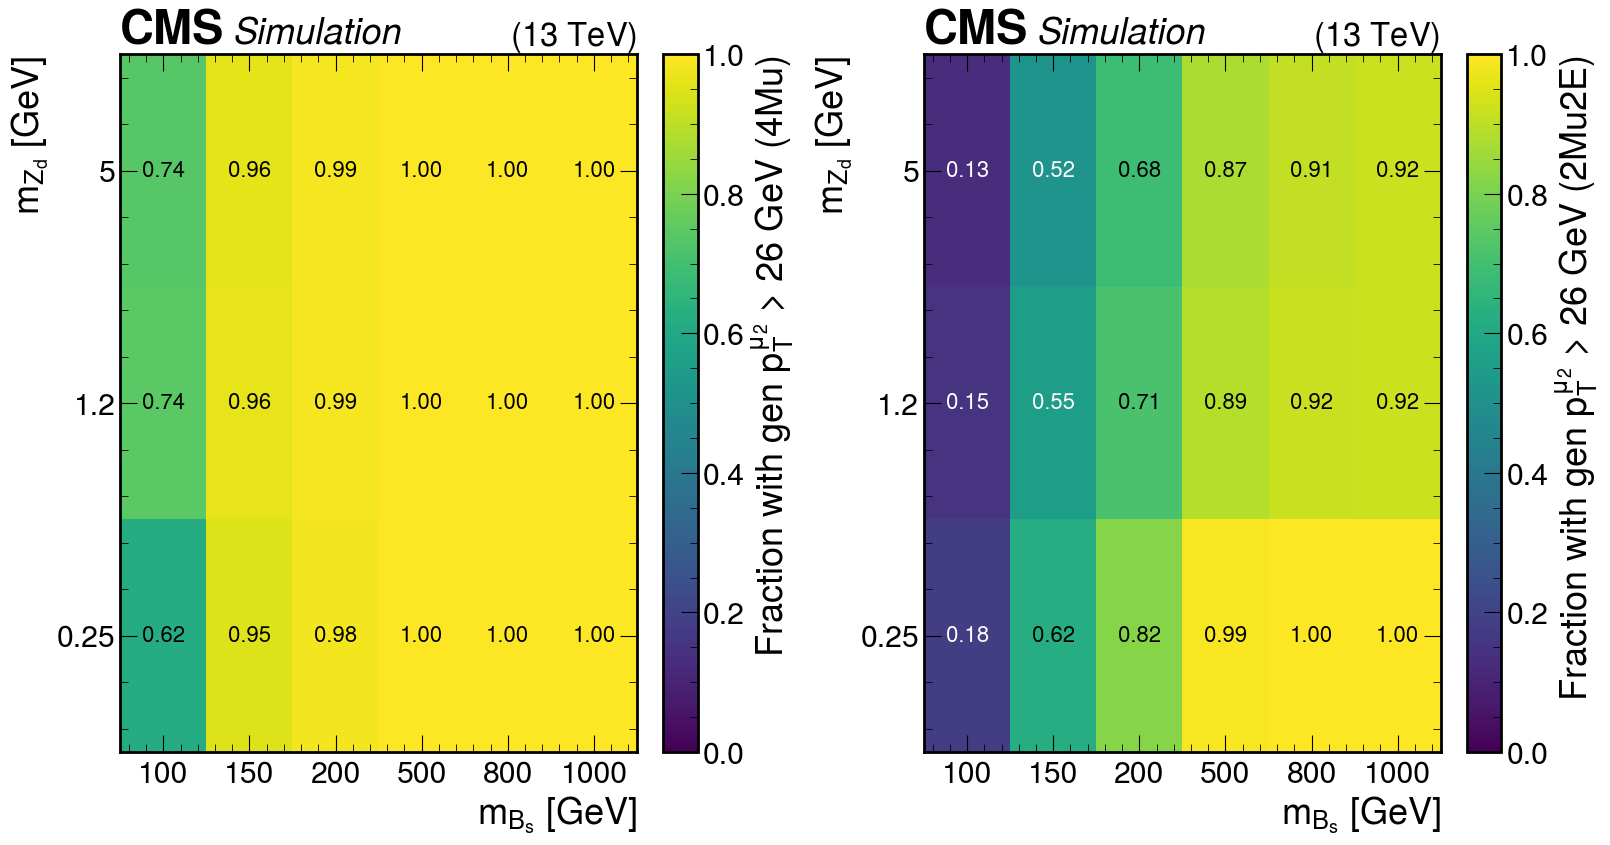

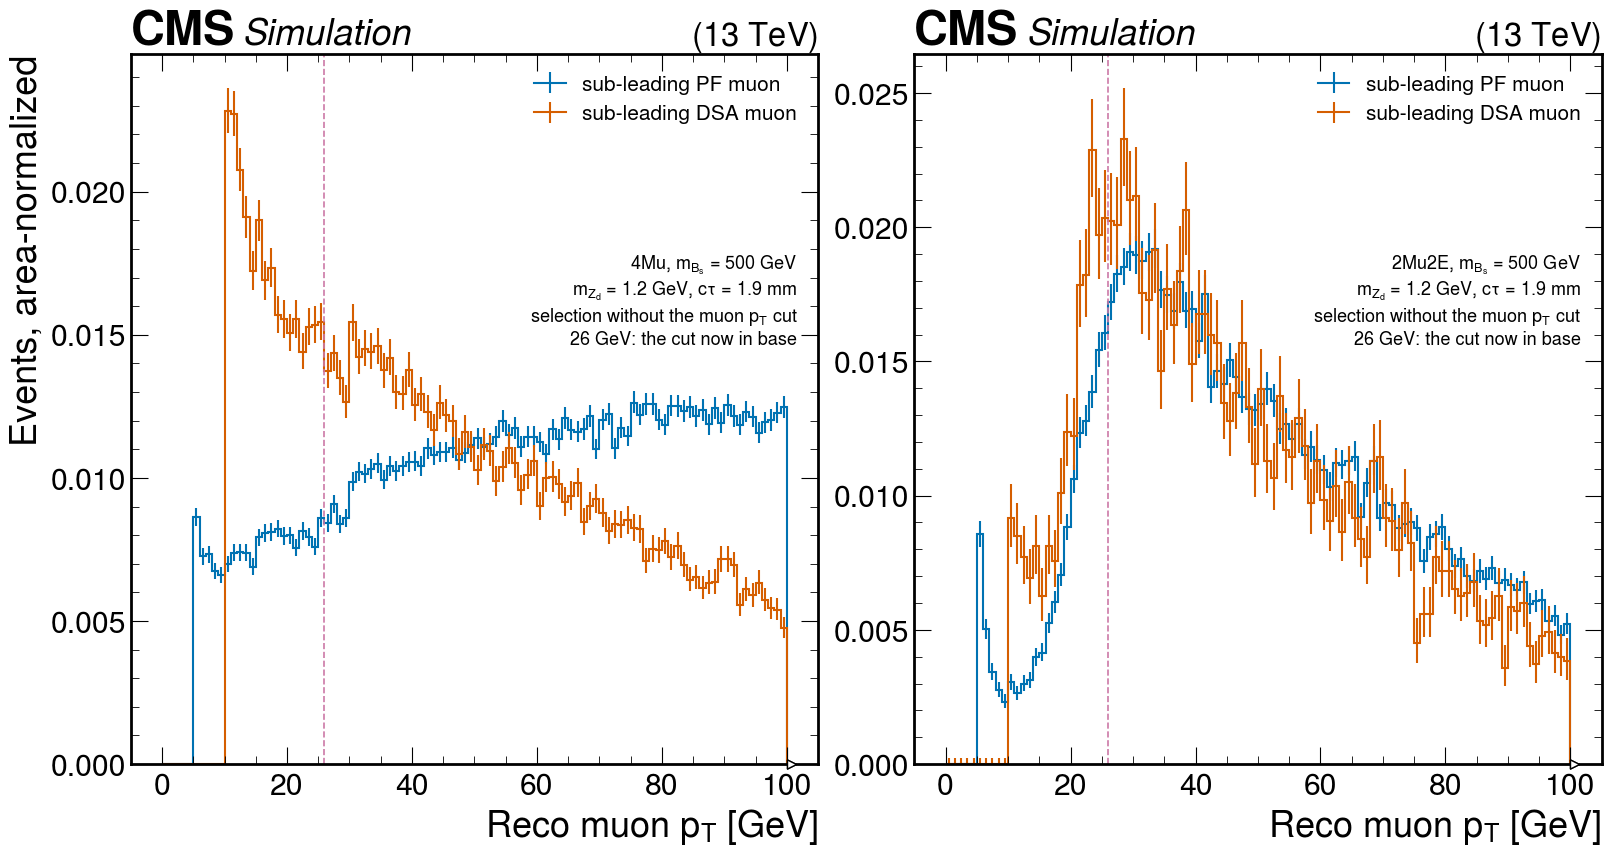

In [7]:
fig, axes = plt.subplots(1, 2, figsize=an_style.WIDE, layout="constrained")
for ax, mode in zip(axes, ["4Mu", "2Mu2E"]):
    grid = np.zeros((len(MZD), len(MBS)))
    for i, mzd in enumerate(MZD):
        for j, mbs in enumerate(MBS):
            fr = [frac_above(lib.get_h(out, s, "genMu1_pt", "genOnly_trigger"), 26.0)
                  for s in lib.select_samples(out, mode=mode, mbs=mbs, mzd=mzd)]
            grid[i, j] = np.nanmedian(fr)
    pcm = ax.pcolormesh(np.arange(len(MBS) + 1), np.arange(len(MZD) + 1), grid,
                        norm=Normalize(0, 1), cmap="viridis")
    fig.colorbar(pcm, ax=ax,
                 label=rf"Fraction with gen $p_T^{{\mu_2}}$ > 26 GeV ({mode})")
    for i in range(len(MZD)):
        for j in range(len(MBS)):
            tc = "black" if pcm.norm(grid[i, j]) > 0.6 else "white"
            ax.text(j + 0.5, i + 0.5, f"{grid[i, j]:.2f}", ha="center",
                    va="center", color=tc, fontsize=16)
    ax.set_xticks(np.arange(len(MBS)) + 0.5, [f"{m:g}" for m in MBS])
    ax.set_yticks(np.arange(len(MZD)) + 0.5, [f"{m:g}" for m in MZD])
    ax.set_xlabel(r"$m_{B_s}$ [GeV]")
    ax.set_ylabel(r"$m_{Z_d}$ [GeV]")
an_style.cms_sim_labels(axes)
an_style.save(fig, "trigger_plateau_cut_retention")

# reconstructed-muon view of the 26 GeV boundary, base selection
picks = [lib.mid_ctau(out, "4Mu", 500.0, 1.2), lib.mid_ctau(out, "2Mu2E", 500.0, 1.2)]
fig, axes = plt.subplots(1, 2, figsize=an_style.WIDE, layout="constrained")
for ax, s in zip(axes, picks):
    hep.histplot(lib.get_h(out, s, "muon1_pt", "base"), ax=ax, density=True,
                 label="sub-leading PF muon", color="#0072B2")
    hep.histplot(lib.get_h(out, s, "dsaMuon1_pt", "base"), ax=ax, density=True,
                 label="sub-leading DSA muon", color="#D55E00")
    ax.axvline(26, color="#CC79A7", ls="--", lw=1.2)
    ax.set_xlabel(r"Reco muon $p_T$ [GeV]")
    ax.legend(fontsize=15, loc="upper right")
    ax.text(0.97, 0.72, lib.format_sample_2line(s)
            + "\nselection without the muon $p_T$ cut"
            + "\n26 GeV: the cut now in base",
            transform=ax.transAxes, ha="right", va="top", fontsize=13)
axes[0].set_ylabel("Events, area-normalized")
an_style.cms_sim_labels(axes)
an_style.save(fig, "trigger_reco_muon_pt_boundary")
print("note: reco muon pT axes end at 100 GeV; the spectra above that are truncated")

## 6. Machine-readable summary

Per-sample event-level trigger efficiency (with binomial uncertainty) and
the median dark-photon $l_{xy}$, written alongside this notebook as
`v3_trigger_efficiency.yml` and committed. Together with the production
cross section and branching fractions from
`sidm/studies/pseudoscalar_xsec` and the filter efficiencies in
`central_genFilterEfficiencies.yml`, these are the generator-level
per-sample factors from which expected signal yields across the grid are
assembled (the normalization chain is spelled out in
`final_state_anatomy_forAN.ipynb`); reconstruction and selection
acceptance and the luminosity enter downstream of everything stored here.
The dark-photon displacement median comes from the 0-500 cm `genAs_lxy`
histogram (5 cm bins), refined with the 0-10 cm `genAs_lxy_lowRange`
histogram when it falls inside the first coarse bin; `null` means more
than half the distribution lies beyond 500 cm.

In [8]:
import yaml

def lxy_median_or_none(name):
    h_full = lib.get_h(out, name, "genAs_lxy")
    tot = h_full.sum(flow=True)
    tot = float(tot.value if hasattr(tot, "value") else tot)
    if tot == 0 or h_full.values().sum() < 0.5 * tot:
        return None  # median beyond the 500 cm histogram range
    med = lib.hist_median_tiered(lib.get_h(out, name, "genAs_lxy_lowRange"),
                                 h_full)
    return round(float(med), 3)

summary = {}
for name in sorted(out):
    eff, err = lib.trigger_eff(out, name)
    summary[name] = {
        "trigger_eff": round(float(eff), 4),
        "trigger_eff_err": round(float(err), 4),
        "median_genA_lxy_cm": lxy_median_or_none(name),
    }
with open("v3_trigger_efficiency.yml", "w") as f:
    f.write(
        "# Event-level dimuon-trigger efficiency per 2018 v10 signal sample:\n"
        "# genOnly_trigger / genOnly event counts from the v3 production\n"
        "# (HLT decision bits stored in the ntuples; unweighted; binomial\n"
        "# uncertainty). median_genA_lxy_cm from the genOnly genAs_lxy\n"
        "# histogram, lowRange-refined (null: median beyond 500 cm).\n"
        "# Generated by trigger_context_forAN.ipynb.\n")
    yaml.safe_dump(summary, f, sort_keys=True)
print(f"wrote v3_trigger_efficiency.yml ({len(summary)} samples)")

wrote v3_trigger_efficiency.yml (180 samples)


## Summary

The dimuon L2 `NoVtx` paths define the analysis acceptance in three truth
variables. Muon $p_T$: the 23-25 GeV thresholds sit in the bulk of the
spectrum at $m_{B_s} \leq 200$ GeV in both channels; above 500 GeV the 4Mu
spectrum clears them almost entirely while 2Mu2E keeps 15-28% of events
below the boundary. Displacement: efficiency persists to
tens-of-centimeter $l_{xy}$ before L2 losses grow. Collimation: efficiency
peaks near $\Delta R(\mu,\mu) \sim 0.02$ and degrades on both sides;
merged pairs below $\Delta R \sim 0.01$ lose L2 reconstruction efficiency,
and wide pairs are soft. Folded over the grid, median event-level
efficiencies span 0.58-0.95 in 4Mu, peaking at $m_{B_s} = 500$ GeV and
declining toward 1000 GeV, and 0.08-0.54 in 2Mu2E, whose single muon pair
carries the whole trigger burden. The 26 GeV plateau cut is nearly free in
4Mu, but costs 8-13% of triggered 2Mu2E events at high mass and more at low
mass, and it lands where the flat-efficiency premise is weakest; its final
accounting belongs with the reconstruction-level selection and the
data-driven trigger corrections in the analysis note.